## 0. Install Library yang Diperlukan

In [ ]:
!pip install pmdarima pycountry openpyxl beautifulsoup4 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 64.6 MB/s eta 0:00:00


## 1. Mount Google Drive & Setup Path

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

BASE_DIR   = '/content/drive/MyDrive/PetaKeheningan'
RAW_DIR    = os.path.join(BASE_DIR, 'raw')
OUTPUT_DIR = os.path.join(BASE_DIR, 'output')

os.makedirs(RAW_DIR,    exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

OWID_PATH = os.path.join(RAW_DIR, 'owid_women_parliament.csv')
WB_PATH   = os.path.join(RAW_DIR, 'worldbank_women_parliament.csv')
GEO_PATH  = os.path.join(RAW_DIR, 'countries.geojson')
IDEA_PATH = os.path.join(RAW_DIR, 'idea_gender_quotas.xlsx')  # diunduh otomatis

print('✅ Google Drive berhasil di-mount')
print(f'   Base  : {BASE_DIR}')
print(f'   Raw   : {RAW_DIR}')
print(f'   Output: {OUTPUT_DIR}')


Mounted at /content/drive
✅ Google Drive berhasil di-mount
   Base  : /content/drive/MyDrive/PetaKeheningan
   Raw   : /content/drive/MyDrive/PetaKeheningan/raw
   Output: /content/drive/MyDrive/PetaKeheningan/output


## 2. Validasi Ketersediaan File

In [ ]:
import os

files_to_check = {
    'OWID (primer)': OWID_PATH,
    'World Bank (validasi)': WB_PATH,
    'Natural Earth GeoJSON (spasial)': GEO_PATH,
}

all_ok = True
for label, path in files_to_check.items():
    exists = os.path.exists(path)
    size   = f'{os.path.getsize(path)/1024:.1f} KB' if exists else '—'
    status = '✅' if exists else '❌ TIDAK DITEMUKAN'
    print(f'{status}  {label}')
    print(f'       {path} ({size})')
    if not exists:
        all_ok = False

if not all_ok:
    print('\n⚠️  Ada file yang belum diupload. Pastikan nama file persis sama.')
else:
    print('\n🎉 Semua file manual tersedia! Data IDEA akan diunduh otomatis di sel 4.3.')


✅  OWID (primer)
       /content/drive/MyDrive/PetaKeheningan/raw/owid_women_parliament.csv (513.8 KB)
✅  World Bank (validasi)
       /content/drive/MyDrive/PetaKeheningan/raw/worldbank_women_parliament.csv (166.3 KB)
✅  Natural Earth GeoJSON (spasial)
       /content/drive/MyDrive/PetaKeheningan/raw/countries.geojson (14300.4 KB)

🎉 Semua file manual tersedia! Data IDEA akan diunduh otomatis di sel 4.3.


## 3. Import Library

In [ ]:
import pandas as pd
import numpy as np
import json
import warnings
import pycountry
import re

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Library berhasil diimport")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")

✅ Library berhasil diimport
   pandas  : 2.2.2
   numpy   : 2.0.2


## 4. Load Dataset
### 4.1 Our World in Data (Sumber Primer)

In [ ]:
df_owid = pd.read_csv(OWID_PATH)

print("=" * 55)
print("📊 Our World in Data — Preview")
print("=" * 55)
print(f"Shape    : {df_owid.shape[0]:,} baris × {df_owid.shape[1]} kolom")
print(f"Kolom    : {df_owid.columns.tolist()}")
print(f"Tipe data:\n{df_owid.dtypes.to_string()}")
print()
print(df_owid.head(5))

📊 Our World in Data — Preview
Shape    : 17,148 baris × 5 kolom
Kolom    : ['Entity', 'Code', 'Year', 'Lower chamber female legislators', 'World region according to OWID']
Tipe data:
Entity                               object
Code                                 object
Year                                  int64
Lower chamber female legislators    float64
World region according to OWID       object

        Entity Code  Year  Lower chamber female legislators  \
0  Afghanistan  AFG  1923                              0.00   
1  Afghanistan  AFG  1924                              0.00   
2  Afghanistan  AFG  1925                              0.00   
3  Afghanistan  AFG  1926                              0.00   
4  Afghanistan  AFG  1927                              0.00   

  World region according to OWID  
0                           Asia  
1                           Asia  
2                           Asia  
3                           Asia  
4                           Asia  


### 4.2 World Bank (Validasi)

In [ ]:
df_wb_raw = pd.read_csv(WB_PATH, skiprows=4)

print("=" * 55)
print("🏦 World Bank — Preview (raw)")
print("=" * 55)
print(f"Shape: {df_wb_raw.shape}")
print(df_wb_raw.iloc[:3, :8])

🏦 World Bank — Preview (raw)
Shape: (266, 71)
                  Country Name Country Code  \
0                        Aruba          ABW   
1  Africa Eastern and Southern          AFE   
2                  Afghanistan          AFG   

                                      Indicator Name  Indicator Code  1960  \
0  Proportion of seats held by women in national ...  SG.GEN.PARL.ZS   NaN   
1  Proportion of seats held by women in national ...  SG.GEN.PARL.ZS   NaN   
2  Proportion of seats held by women in national ...  SG.GEN.PARL.ZS   NaN   

   1961  1962  1963  
0   NaN   NaN   NaN  
1   NaN   NaN   NaN  
2   NaN   NaN   NaN  


### 4.3 IDEA Gender Quotas — Download Otomatis dari idea.int

In [ ]:
import requests, os, time

IDEA_EXPORT_URL = 'https://www.idea.int/data-tools/export-gqd?type=countries'
IDEA_AUTO_SUCCESS = False

def download_idea_xlsx(save_path, max_retries=3):
    if os.path.exists(save_path):
        size_kb = os.path.getsize(save_path) / 1024
        print(f'⏩ File sudah ada ({size_kb:.1f} KB), skip download.')
        print(f'   Hapus file tersebut jika ingin download ulang.')
        return True

    hdrs = {
        'User-Agent': 'Mozilla/5.0 (compatible; research-script/1.0)',
        'Accept': ('application/vnd.openxmlformats-officedocument'
                   '.spreadsheetml.sheet,application/octet-stream,*/*'),
        'Referer': 'https://www.idea.int/data-tools/data/gender-quotas-database/countries',
    }
    for attempt in range(1, max_retries + 1):
        try:
            print(f'🌐 Mengunduh dari IDEA (percobaan {attempt}/{max_retries})...')
            r = requests.get(IDEA_EXPORT_URL, headers=hdrs, timeout=60, allow_redirects=True)
            r.raise_for_status()
            ctype = r.headers.get('Content-Type', '')
            print(f'   HTTP {r.status_code} | Content-Type: {ctype} | {len(r.content)/1024:.1f} KB')

            if b'<!DOCTYPE' in r.content[:50] or b'<html' in r.content[:50]:
                raise ValueError('Response berupa HTML, bukan file Excel. Coba lagi nanti.')
            with open(save_path, 'wb') as f:
                f.write(r.content)
            print(f'✅ Tersimpan: {save_path}')
            return True
        except Exception as e:
            print(f'   ⚠️  Percobaan {attempt} gagal: {e}')
            if attempt < max_retries:
                wait = 5 * attempt
                print(f'   Menunggu {wait} detik...')
                time.sleep(wait)
    return False

IDEA_AUTO_SUCCESS = download_idea_xlsx(IDEA_PATH)

if not IDEA_AUTO_SUCCESS:
    print()
    print('=' * 55)
    print('❌ Download otomatis gagal.')
    print('   ➜ Lanjutkan ke sel FALLBACK di bawah ini.')
    print('=' * 55)


🌐 Mengunduh dari IDEA (percobaan 1/3)...
   HTTP 200 | Content-Type: application/vnd.openxmlformats-officedocument.spreadsheetml.sheet | 12.1 KB
✅ Tersimpan: /content/drive/MyDrive/PetaKeheningan/raw/idea_gender_quotas.xlsx


#### Fallback: Scraping Halaman IDEA (Jika Gagal)

In [ ]:
# Jalankan hanya jika IDEA_AUTO_SUCCESS == False
if not IDEA_AUTO_SUCCESS:
    from bs4 import BeautifulSoup
    import pandas as pd, requests, os

    URL = 'https://www.idea.int/data-tools/data/gender-quotas-database/countries'
    hdrs = {'User-Agent': 'Mozilla/5.0 (compatible; research-script/1.0)'}

    print('🌐 Scraping tabel dari halaman IDEA countries...')
    resp = requests.get(URL, headers=hdrs, timeout=60)
    resp.raise_for_status()
    soup = BeautifulSoup(resp.text, 'html.parser')

    table = soup.find('table')
    if table is None:
        raise RuntimeError('Tabel tidak ditemukan. Struktur halaman IDEA mungkin berubah.')

    # Header
    thead = table.find('thead')
    col_names = [th.get_text(strip=True) for th in thead.find_all('th')] if thead else []

    # Baris data
    rows = []
    for tr in table.find('tbody').find_all('tr'):
        tds = tr.find_all('td')
        if not tds:
            continue
        row = [td.get_text(separator=' ', strip=True) for td in tds]
        rows.append(row)

    # Sesuaikan kolom
    max_cols = max(len(r) for r in rows)
    while len(col_names) < max_cols:
        col_names.append(f'col_{len(col_names)}')
    col_names = col_names[:max_cols]

    df_scraped = pd.DataFrame(rows, columns=col_names)

    # Simpan sebagai CSV fallback & update IDEA_PATH global
    IDEA_PATH_CSV = IDEA_PATH.replace('.xlsx', '_scraped.csv')
    df_scraped.to_csv(IDEA_PATH_CSV, index=False)
    IDEA_PATH = IDEA_PATH_CSV  # override path global untuk sel selanjutnya

    print(f'✅ Scraping selesai: {len(df_scraped)} baris')
    print(f'   Disimpan: {IDEA_PATH}')
    print(df_scraped.iloc[:3, :3])
else:
    print('✅ Download otomatis berhasil — sel ini dilewati.')


### 4.4 Natural Earth GeoJSON (Spasial)

In [ ]:
with open(GEO_PATH, 'r', encoding='utf-8') as f:
    geo_data = json.load(f)

n_features = len(geo_data['features'])
sample_props = list(geo_data['features'][0]['properties'].keys())

print("=" * 55)
print("🌍 Natural Earth GeoJSON — Info")
print("=" * 55)
print(f"Jumlah features : {n_features}")
print(f"Property keys   : {sample_props}")
print()
print("Sample feature (properties):")
print(json.dumps(geo_data['features'][0]['properties'], indent=2))

🌍 Natural Earth GeoJSON — Info
Jumlah features : 258
Property keys   : ['name', 'ISO3166-1-Alpha-3', 'ISO3166-1-Alpha-2']

Sample feature (properties):
{
  "name": "Indonesia",
  "ISO3166-1-Alpha-3": "IDN",
  "ISO3166-1-Alpha-2": "ID"
}


## 5. Preprocessing
### 5.1 Preprocessing OWID — Dataset Primer

In [ ]:
print('Kolom asli OWID:', df_owid.columns.tolist())
print('Shape          :', df_owid.shape)
print(df_owid.head(3))

# Normalisasi nama kolom
df_owid.columns = (
    df_owid.columns
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', '_', regex=True)
    .str.replace(r'[^a-z0-9_]', '', regex=True)
)
print('\nKolom setelah normalisasi:', df_owid.columns.tolist())

# Auto-detect kolom berdasarkan prioritas

# Kolom country
CAND_COUNTRY = ['entity', 'country', 'name', 'country_name']
COL_COUNTRY  = next((c for c in CAND_COUNTRY if c in df_owid.columns), None)
if COL_COUNTRY is None:
    # Fallback: kolom string pertama
    COL_COUNTRY = df_owid.select_dtypes(include='object').columns[0]

# Kolom ISO3 / code
CAND_CODE   = ['code', 'iso3', 'iso_code', 'country_code', 'alpha_3']
COL_CODE    = next((c for c in CAND_CODE if c in df_owid.columns), None)
if COL_CODE is None:
    # Fallback: cari kolom string pendek (ISO3 = tepat 3 huruf)
    for c in df_owid.select_dtypes(include='object').columns:
        sample = df_owid[c].dropna().head(20)
        if sample.str.len().between(2, 4).mean() > 0.8:
            COL_CODE = c
            break

# Kolom year
CAND_YEAR   = ['year', 'date', 'yr', 'time']
COL_YEAR    = next((c for c in CAND_YEAR if c in df_owid.columns), None)
if COL_YEAR is None:
    for c in df_owid.select_dtypes(include='number').columns:
        sample = df_owid[c].dropna()
        if sample.between(1900, 2100).mean() > 0.9:
            COL_YEAR = c
            break

# Kolom nilai persentase: kolom numerik selain year
numeric_cols = df_owid.select_dtypes(include='number').columns.tolist()
value_candidates = [c for c in numeric_cols if c != COL_YEAR]
# Pilih kolom numerik dengan nilai rata-rata dalam rentang [0, 100] (persentase)
COL_VALUE = None
for c in value_candidates:
    sample = df_owid[c].dropna()
    if len(sample) > 0 and sample.between(0, 100).mean() > 0.8:
        COL_VALUE = c
        break
if COL_VALUE is None and value_candidates:
    COL_VALUE = value_candidates[0]  # fallback kolom numerik pertama

print(f'\nHasil auto-detect:')
print(f'  COL_COUNTRY = "{COL_COUNTRY}"')
print(f'  COL_CODE    = "{COL_CODE}"  ← ISO3 (None = akan di-generate dari nama negara)')
print(f'  COL_YEAR    = "{COL_YEAR}"')
print(f'  COL_VALUE   = "{COL_VALUE}"')

# Pastikan semua kolom penting terdeteksi
assert COL_COUNTRY is not None, f'Kolom country tidak terdeteksi. Kolom: {df_owid.columns.tolist()}'
assert COL_YEAR    is not None, f'Kolom year tidak terdeteksi. Kolom: {df_owid.columns.tolist()}'
assert COL_VALUE   is not None, f'Kolom nilai tidak terdeteksi. Kolom: {df_owid.columns.tolist()}'


Kolom asli OWID: ['Entity', 'Code', 'Year', 'Lower chamber female legislators', 'World region according to OWID']
Shape          : (17148, 5)
        Entity Code  Year  Lower chamber female legislators  \
0  Afghanistan  AFG  1923                              0.00   
1  Afghanistan  AFG  1924                              0.00   
2  Afghanistan  AFG  1925                              0.00   

  World region according to OWID  
0                           Asia  
1                           Asia  
2                           Asia  

Kolom setelah normalisasi: ['entity', 'code', 'year', 'lower_chamber_female_legislators', 'world_region_according_to_owid']

Hasil auto-detect:
  COL_COUNTRY = "entity"
  COL_CODE    = "code"  ← ISO3 (None = akan di-generate dari nama negara)
  COL_YEAR    = "year"
  COL_VALUE   = "lower_chamber_female_legislators"


In [ ]:
import pycountry

# Rename ke kolom standar pipeline
rename_map = {
    COL_COUNTRY : 'country',
    COL_YEAR    : 'year',
    COL_VALUE   : 'pct_women',
}
if COL_CODE is not None:
    rename_map[COL_CODE] = 'iso3'

df_owid = df_owid.rename(columns=rename_map)

# Jika kolom 'iso3' tidak ada, generate dari nama negara
if 'iso3' not in df_owid.columns:
    print('⚠️  Kolom ISO3 tidak ada — generate otomatis dari nama negara...')

    MANUAL_ISO3 = {
        'Bolivia'                         : 'BOL',
        'Bosnia and Herzegovina'          : 'BIH',
        'Cabo Verde'                      : 'CPV',
        "Cote d'Ivoire"                   : 'CIV',
        "Côte d'Ivoire"                   : 'CIV',
        'Congo'                           : 'COG',
        'Democratic Republic of Congo'    : 'COD',
        'Czechia'                         : 'CZE',
        'Czech Republic'                  : 'CZE',
        'Eswatini'                        : 'SWZ',
        'Kosovo'                          : 'XKX',
        'Micronesia (country)'            : 'FSM',
        'Moldova'                         : 'MDA',
        'North Macedonia'                 : 'MKD',
        'Palestine'                       : 'PSE',
        'Russia'                          : 'RUS',
        'Saint Kitts and Nevis'           : 'KNA',
        'Saint Lucia'                     : 'LCA',
        'Saint Vincent and the Grenadines': 'VCT',
        'Sao Tome and Principe'           : 'STP',
        'South Korea'                     : 'KOR',
        'Syria'                           : 'SYR',
        'Taiwan'                          : 'TWN',
        'Tanzania'                        : 'TZA',
        'Turkey'                          : 'TUR',
        'United States'                   : 'USA',
        'Vatican'                         : 'VAT',
        'Vietnam'                         : 'VNM',
    }

    _cache = {}
    def country_to_iso3(name):
        if name in _cache:
            return _cache[name]
        if name in MANUAL_ISO3:
            _cache[name] = MANUAL_ISO3[name]
            return _cache[name]
        try:
            _cache[name] = pycountry.countries.lookup(name).alpha_3
        except LookupError:
            try:
                _cache[name] = pycountry.countries.search_fuzzy(name)[0].alpha_3
            except Exception:
                _cache[name] = None
        return _cache[name]

    df_owid['iso3'] = df_owid['country'].apply(country_to_iso3)
    n_resolved = df_owid['iso3'].notna().sum()
    n_total    = len(df_owid)
    print(f'   Berhasil di-resolve : {n_resolved:,}/{n_total:,} baris')

    # Tampilkan negara yang gagal (biasanya aggregate: World, High income, dsb)
    unresolved = df_owid[df_owid['iso3'].isna()]['country'].unique()
    if len(unresolved) > 0:
        print(f'   Tidak ter-resolve ({len(unresolved)}): {unresolved[:15].tolist()}')
        print('   → Baris ini akan difilter sebagai baris aggregate.')
else:
    print('✅ Kolom iso3 sudah ada dari CSV.')

# Pertahankan hanya kolom relevan
df_owid = df_owid[['country', 'iso3', 'year', 'pct_women']].copy()

# Tipe data
df_owid['year']      = pd.to_numeric(df_owid['year'],      errors='coerce').astype('Int64')
df_owid['pct_women'] = pd.to_numeric(df_owid['pct_women'], errors='coerce')
df_owid['country']   = df_owid['country'].astype(str).str.strip()
df_owid['iso3']      = df_owid['iso3'].astype(str).str.strip().str.upper()
df_owid['iso3']      = df_owid['iso3'].replace('NONE', pd.NA)

# Filter tahun 1997–2025
df_owid = df_owid[df_owid['year'].between(1997, 2025)]

# Hapus baris aggregate (iso3 kosong = aggregate seperti World)
df_owid = df_owid.dropna(subset=['iso3'])

# Hapus duplikat
df_owid = df_owid.drop_duplicates(subset=['iso3', 'year'], keep='last')

# Laporan
print(f'\n✅ OWID Preprocessing Selesai')
print(f'   Negara unik   : {df_owid["iso3"].nunique()}')
print(f'   Rentang tahun : {df_owid["year"].min()}–{df_owid["year"].max()}')
print(f'   Missing pct_women: {df_owid["pct_women"].isna().sum()} baris')
print(f'   Total baris   : {len(df_owid):,}')
print()
print(df_owid.head(8))


✅ Kolom iso3 sudah ada dari CSV.

✅ OWID Preprocessing Selesai
   Negara unik   : 185
   Rentang tahun : 1997–2025
   Missing pct_women: 0 baris
   Total baris   : 5,136

        country iso3  year  pct_women
64  Afghanistan  AFG  2005      27.31
65  Afghanistan  AFG  2006      27.31
66  Afghanistan  AFG  2007      27.69
67  Afghanistan  AFG  2008      27.31
68  Afghanistan  AFG  2009      27.31
69  Afghanistan  AFG  2010      27.71
70  Afghanistan  AFG  2011      27.71
71  Afghanistan  AFG  2012      27.71


### 5.2 Preprocessing World Bank — Reshape Wide→Long

In [ ]:
# Identifikasi kolom tahun (kolom berisi angka 4-digit ≥ 1990)
year_cols = [c for c in df_wb_raw.columns if re.fullmatch(r'\d{4}', str(c)) and int(c) >= 1990]

# Identifikasi kolom meta
id_vars = ['Country Name', 'Country Code']
id_vars = [c for c in id_vars if c in df_wb_raw.columns]

if not id_vars:
    # Fallback jika nama kolom sedikit berbeda
    id_vars = df_wb_raw.columns[:2].tolist()
    print(f"⚠️  Menggunakan fallback id_vars: {id_vars}")

print(f"Kolom tahun ditemukan: {len(year_cols)} ({year_cols[0]}–{year_cols[-1]})")

df_wb = (
    df_wb_raw[id_vars + year_cols]
    .melt(id_vars=id_vars, var_name='year', value_name='pct_women_wb')
)

# Rename ke standar
df_wb.columns = ['country_wb', 'iso3', 'year', 'pct_women_wb']

# Tipe data
df_wb['year']         = pd.to_numeric(df_wb['year'], errors='coerce').astype('Int64')
df_wb['pct_women_wb'] = pd.to_numeric(df_wb['pct_women_wb'], errors='coerce')
df_wb['iso3']         = df_wb['iso3'].str.strip().str.upper()

# Filter tahun 1997–2025
df_wb = df_wb[df_wb['year'].between(1997, 2025)]
df_wb = df_wb.dropna(subset=['pct_women_wb'])

print(f"✅ World Bank Preprocessing Selesai")
print(f"   Negara unik : {df_wb['iso3'].nunique()}")
print(f"   Total baris : {len(df_wb):,}")
print()
print(df_wb.head(5))

Kolom tahun ditemukan: 36 (1990–2025)
✅ World Bank Preprocessing Selesai
   Negara unik : 241
   Total baris : 6,592

                       country_wb iso3  year  pct_women_wb
1863  Africa Eastern and Southern  AFE  1997         11.83
1866                       Angola  AGO  1997          9.55
1868                      Andorra  AND  1997          7.14
1869                   Arab World  ARB  1997          3.75
1870         United Arab Emirates  ARE  1997          0.00


### 5.3 Preprocessing IDEA Gender Quotas

In [ ]:
import pandas as pd, os, pycountry

# Load IDEA: xlsx (otomatis) atau csv (fallback scraping)
print(f'Loading IDEA dari: {IDEA_PATH}')
if IDEA_PATH.endswith('.xlsx') and os.path.exists(IDEA_PATH):
    xl = pd.ExcelFile(IDEA_PATH)
    print(f'Sheet: {xl.sheet_names}')
    df_idea = pd.read_excel(IDEA_PATH, sheet_name=xl.sheet_names[0], header=0)
else:
    df_idea = pd.read_csv(IDEA_PATH)

print(f'Shape awal : {df_idea.shape}')
print(f'Kolom      : {df_idea.columns.tolist()}')
print(df_idea.head(3))

# Normalisasi nama kolom
df_idea.columns = (
    df_idea.columns.astype(str).str.strip().str.lower()
    .str.replace(r'\s+', '_', regex=True)
    .str.replace(r'[^a-z0-9_]', '', regex=True)
)
print('\nKolom setelah normalisasi:', df_idea.columns.tolist())

# Auto-detect kolom country & quota
IDEA_COUNTRY = next(
    (c for c in df_idea.columns if any(k in c for k in ['country','name','nation'])),
    df_idea.columns[0]
)
IDEA_QUOTA = next(
    (c for c in df_idea.columns if 'quota' in c and 'target' not in c and 'pct' not in c),
    None
)
print(f'\nKolom terdeteksi  → country: {IDEA_COUNTRY} | quota: {IDEA_QUOTA}')

# Rename
rename_map = {IDEA_COUNTRY: 'country_idea'}
if IDEA_QUOTA:
    rename_map[IDEA_QUOTA] = 'quota_type_raw'
df_idea = df_idea.rename(columns=rename_map)

# Bersihkan nama negara (hapus suffix sistem elektoral misal '(List PR)')
df_idea['country_idea'] = (
    df_idea['country_idea'].astype(str).str.strip()
    .str.replace(r'\s*\([^)]*\)\s*$', '', regex=True).str.strip()
)

# Klasifikasi ke 4 kategori kuota standar
def classify_quota(val):
    if not isinstance(val, str) or val.strip() in ('', 'nan'):
        return 'No Quota'
    v = val.lower()
    if 'reserved' in v:
        return 'Reserved Seats'
    if 'legislated' in v or 'legal' in v or 'constitutional' in v:
        return 'Legislated Candidate Quota'
    if 'voluntary' in v or 'party' in v:
        return 'Voluntary Party Quota'
    return 'No Quota'

df_idea['quota_type'] = (
    df_idea['quota_type_raw'].apply(classify_quota)
    if 'quota_type_raw' in df_idea.columns
    else 'No Quota'
)

# Lookup ISO3 via pycountry
MANUAL_ISO3 = {
    'Bolivia'                            : 'BOL',
    'Bosnia and Herzegovina'             : 'BIH',
    'Cabo Verde'                         : 'CPV',
    "Côte d'Ivoire"                      : 'CIV',
    'Korea, Republic of'                 : 'KOR',
    'Kosovo'                             : 'XKX',
    'Moldova, Republic of'               : 'MDA',
    'North Macedonia, Republic of'       : 'MKD',
    'Republic of The Congo (Brazzaville)': 'COG',
    'São Tomé and Príncipe'              : 'STP',
    'State of Palestine'                 : 'PSE',
    'Tanzania, United Republic of'       : 'TZA',
    'Viet Nam'                           : 'VNM',
    'Taiwan'                             : 'TWN',
    'Eswatini'                           : 'SWZ',
    'Czechia'                            : 'CZE',
}

def get_iso3(name):
    if name in MANUAL_ISO3:
        return MANUAL_ISO3[name]
    try:
        return pycountry.countries.lookup(name).alpha_3
    except LookupError:
        try:
            return pycountry.countries.search_fuzzy(name)[0].alpha_3
        except Exception:
            return None

df_idea['iso3'] = df_idea['country_idea'].apply(get_iso3)

unresolved = df_idea[df_idea['iso3'].isna()]['country_idea'].tolist()
if unresolved:
    print(f'\n⚠️  {len(unresolved)} negara tidak ter-resolve ke ISO3: {unresolved}')

# Deduplikasi: kuota paling kuat per negara
prio = {'Reserved Seats': 3, 'Legislated Candidate Quota': 2,
        'Voluntary Party Quota': 1, 'No Quota': 0}
df_idea['_prio'] = df_idea['quota_type'].map(prio).fillna(0)
df_idea = (
    df_idea.sort_values('_prio', ascending=False)
    .drop_duplicates(subset='iso3', keep='first')
    .drop(columns=['_prio'])
    .reset_index(drop=True)
)

print(f'\n✅ IDEA Preprocessing Selesai')
print(f'   Negara dengan kuota     : {len(df_idea)}')
print(f'   ISO3 berhasil di-resolve: {df_idea["iso3"].notna().sum()}')
print('\nDistribusi quota_type:')
print(df_idea['quota_type'].value_counts().to_string())
print()
print(df_idea[['iso3','country_idea','quota_type']].head(10))


Loading IDEA dari: /content/drive/MyDrive/PetaKeheningan/raw/idea_gender_quotas.xlsx
Sheet: ['Worksheet']
Shape awal : (140, 5)
Kolom      : ['Country', 'Quota Type(s)', 'Total women in Single/Lower House', 'Percentage of women in Single/ Lower House', 'Gender Quota Target(s)']
   Country                                      Quota Type(s)  \
0  Albania  Legislated quotas at the Sub-national level\nL...   
1  Algeria  Legislated quotas at the Sub-national level\nV...   
2  Andorra  Legislated quotas for the Single/Lower House\n...   

  Total women in Single/Lower House  \
0                         49 of 140   
1                         32 of 407   
2                          14 of 28   

  Percentage of women in Single/ Lower House  \
0                                        35%   
1                                         8%   
2                                        50%   

                              Gender Quota Target(s)  
0  Gender Quota target for the Single/Lower House...  


### 5.4 Bangun Panel Data Lengkap (Country × Year)

In [ ]:
all_iso3   = df_owid['iso3'].dropna().unique()
all_years  = np.arange(1997, 2026)

panel_index = pd.MultiIndex.from_product(
    [all_iso3, all_years], names=['iso3', 'year']
)
df_panel = pd.DataFrame(index=panel_index).reset_index()
df_panel['year'] = df_panel['year'].astype('Int64')

print(f"Panel skeleton: {len(df_panel):,} baris ({len(all_iso3)} negara × {len(all_years)} tahun)")

# Merge OWID
df_panel = df_panel.merge(
    df_owid[['iso3','year','country','pct_women']],
    on=['iso3','year'], how='left'
)

# Isi nama negara (forward fill per grup iso3)
df_panel['country'] = df_panel.groupby('iso3')['country'].transform(
    lambda x: x.ffill().bfill()
)

# Merge World Bank (untuk validasi)
df_panel = df_panel.merge(
    df_wb[['iso3','year','pct_women_wb']],
    on=['iso3','year'], how='left'
)

# Merge IDEA (kuota — satu nilai per negara)
if 'iso3' in df_idea.columns and 'quota_type' in df_idea.columns:
    idea_per_country = (
        df_idea[['iso3','quota_type']]
        .dropna(subset=['iso3'])
        .drop_duplicates(subset='iso3', keep='first')
    )
    df_panel = df_panel.merge(idea_per_country, on='iso3', how='left')
    df_panel['quota_type'] = df_panel['quota_type'].fillna('No Quota')

print(f"\nPanel setelah merge: {df_panel.shape}")
print(f"Missing pct_women  : {df_panel['pct_women'].isna().mean()*100:.1f}%")
print(df_panel.head(8))

Panel skeleton: 5,365 baris (185 negara × 29 tahun)

Panel setelah merge: (5365, 6)
Missing pct_women  : 4.3%
  iso3  year      country  pct_women  pct_women_wb quota_type
0  AFG  1997  Afghanistan        NaN           NaN   No Quota
1  AFG  1998  Afghanistan        NaN           NaN   No Quota
2  AFG  1999  Afghanistan        NaN           NaN   No Quota
3  AFG  2000  Afghanistan        NaN           NaN   No Quota
4  AFG  2001  Afghanistan        NaN           NaN   No Quota
5  AFG  2002  Afghanistan        NaN           NaN   No Quota
6  AFG  2003  Afghanistan        NaN           NaN   No Quota
7  AFG  2004  Afghanistan        NaN           NaN   No Quota


### 5.5 Imputasi Missing Values (Interpolasi Linear per Negara)

In [ ]:
df_panel = df_panel.sort_values(['iso3', 'year']).reset_index(drop=True)

# Catat jumlah missing sebelum
missing_before = df_panel['pct_women'].isna().sum()

df_panel['pct_women_raw'] = df_panel['pct_women'].copy()  # simpan nilai asli

df_panel['pct_women'] = (
    df_panel
    .groupby('iso3')['pct_women']
    .transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
)

# Clip nilai ke rentang [0, 100]
df_panel['pct_women'] = df_panel['pct_women'].clip(0, 100)

missing_after = df_panel['pct_women'].isna().sum()

print("✅ Interpolasi Selesai")
print(f"   Missing sebelum : {missing_before:,}")
print(f"   Missing sesudah : {missing_after:,}  "
      f"({'negara tanpa data sama sekali' if missing_after > 0 else 'semua terisi'})")

# Negara yang masih punya missing (tidak ada data sama sekali di OWID)
if missing_after > 0:
    still_missing = df_panel[df_panel['pct_women'].isna()]['iso3'].unique()
    print(f"   Negara tanpa data: {still_missing.tolist()}")

✅ Interpolasi Selesai
   Missing sebelum : 229
   Missing sesudah : 0  (semua terisi)


### 5.6 Validasi Cross-Check OWID vs World Bank

📊 Cross-Validation OWID vs World Bank
   Pasangan data-poin : 4,687
   MAE (selisih rata) : 0.391 poin persentase
   Korelasi Pearson   : 0.9945


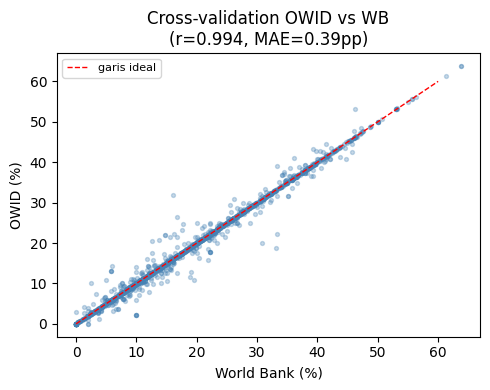

   Plot disimpan ke: /content/drive/MyDrive/PetaKeheningan/output/crossval_owid_wb.png


In [ ]:
import matplotlib.pyplot as plt

# Baris yang punya data dari kedua sumber
df_both = df_panel.dropna(subset=['pct_women', 'pct_women_wb']).copy()
df_both['diff'] = (df_both['pct_women'] - df_both['pct_women_wb']).abs()

n_pairs = len(df_both)
mae_xval = df_both['diff'].mean()
r_corr   = df_both['pct_women'].corr(df_both['pct_women_wb'])

print("📊 Cross-Validation OWID vs World Bank")
print(f"   Pasangan data-poin : {n_pairs:,}")
print(f"   MAE (selisih rata) : {mae_xval:.3f} poin persentase")
print(f"   Korelasi Pearson   : {r_corr:.4f}")

# Scatter plot cepat
fig, ax = plt.subplots(figsize=(5,4))
sample = df_both.sample(min(2000, len(df_both)), random_state=42)
ax.scatter(sample['pct_women_wb'], sample['pct_women'],
           alpha=0.3, s=8, color='steelblue')
ax.plot([0,60],[0,60], 'r--', lw=1, label='garis ideal')
ax.set_xlabel('World Bank (%)')
ax.set_ylabel('OWID (%)')
ax.set_title(f'Cross-validation OWID vs WB\n(r={r_corr:.3f}, MAE={mae_xval:.2f}pp)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'crossval_owid_wb.png'), dpi=120)
plt.show()
print(f"   Plot disimpan ke: {OUTPUT_DIR}/crossval_owid_wb.png")

### 5.7 Feature Engineering — Kolom Tambahan untuk Analisis

In [ ]:
# Perubahan tahunan (delta)
df_panel['delta_pct'] = (
    df_panel
    .groupby('iso3')['pct_women']
    .diff()  # nilai_tahun_t − nilai_tahun_(t-1)
)

#  Flag paritas (≥ 50%)
df_panel['reached_parity'] = df_panel['pct_women'] >= 50.0

#  Milestone: tahun pertama melewati 30%
def first_year_above(group, threshold):
    above = group[group['pct_women'] >= threshold]
    return above['year'].min() if len(above) > 0 else pd.NA

milestone_30 = (
    df_panel.groupby('iso3')
    .apply(lambda g: first_year_above(g, 30.0))
    .rename('milestone_30pct')
    .reset_index()
)
milestone_50 = (
    df_panel.groupby('iso3')
    .apply(lambda g: first_year_above(g, 50.0))
    .rename('milestone_50pct')
    .reset_index()
)

df_panel = df_panel.merge(milestone_30, on='iso3', how='left')
df_panel = df_panel.merge(milestone_50, on='iso3', how='left')

#  Kawasan (region)

region_map = {
    'AFG':'Asia-Pasifik','BGD':'Asia-Pasifik','BTN':'Asia-Pasifik','CHN':'Asia-Pasifik',
    'IDN':'Asia-Pasifik','IND':'Asia-Pasifik','JPN':'Asia-Pasifik','KHM':'Asia-Pasifik',
    'KOR':'Asia-Pasifik','LAO':'Asia-Pasifik','LKA':'Asia-Pasifik','MMR':'Asia-Pasifik',
    'MNG':'Asia-Pasifik','MYS':'Asia-Pasifik','NPL':'Asia-Pasifik','PAK':'Asia-Pasifik',
    'PHL':'Asia-Pasifik','PNG':'Asia-Pasifik','SGP':'Asia-Pasifik','THA':'Asia-Pasifik',
    'VNM':'Asia-Pasifik','AUS':'Asia-Pasifik','NZL':'Asia-Pasifik','FJI':'Asia-Pasifik',
    # Amerika
    'ARG':'Amerika','BLZ':'Amerika','BOL':'Amerika','BRA':'Amerika','CAN':'Amerika',
    'CHL':'Amerika','COL':'Amerika','CRI':'Amerika','CUB':'Amerika','DOM':'Amerika',
    'ECU':'Amerika','GTM':'Amerika','GUY':'Amerika','HND':'Amerika','HTI':'Amerika',
    'JAM':'Amerika','MEX':'Amerika','NIC':'Amerika','PAN':'Amerika','PER':'Amerika',
    'PRY':'Amerika','SLV':'Amerika','SUR':'Amerika','TTO':'Amerika','URY':'Amerika',
    'USA':'Amerika','VEN':'Amerika',
    # Eropa
    'ALB':'Eropa','AND':'Eropa','AUT':'Eropa','BEL':'Eropa','BGR':'Eropa','BIH':'Eropa',
    'BLR':'Eropa','CHE':'Eropa','CYP':'Eropa','CZE':'Eropa','DEU':'Eropa','DNK':'Eropa',
    'ESP':'Eropa','EST':'Eropa','FIN':'Eropa','FRA':'Eropa','GBR':'Eropa','GRC':'Eropa',
    'HRV':'Eropa','HUN':'Eropa','IRL':'Eropa','ISL':'Eropa','ITA':'Eropa','LTU':'Eropa',
    'LUX':'Eropa','LVA':'Eropa','MDA':'Eropa','MKD':'Eropa','MLT':'Eropa','MNE':'Eropa',
    'NLD':'Eropa','NOR':'Eropa','POL':'Eropa','PRT':'Eropa','ROU':'Eropa','RUS':'Eropa',
    'SRB':'Eropa','SVK':'Eropa','SVN':'Eropa','SWE':'Eropa','UKR':'Eropa',
    # MENA
    'ARE':'MENA','BHR':'MENA','DZA':'MENA','EGY':'MENA','IRN':'MENA','IRQ':'MENA',
    'ISR':'MENA','JOR':'MENA','KWT':'MENA','LBN':'MENA','LBY':'MENA','MAR':'MENA',
    'OMN':'MENA','PSE':'MENA','QAT':'MENA','SAU':'MENA','SDN':'MENA','SYR':'MENA',
    'TUN':'MENA','TUR':'MENA','YEM':'MENA',
}

df_panel['region'] = df_panel['iso3'].map(region_map).fillna('Afrika')

print("✅ Feature Engineering Selesai")
print(f"   Kolom panel: {df_panel.columns.tolist()}")
print(f"   Shape      : {df_panel.shape}")
print()
print("Distribusi region:")
print(df_panel.drop_duplicates('iso3')['region'].value_counts().to_string())

✅ Feature Engineering Selesai
   Kolom panel: ['iso3', 'year', 'country', 'pct_women', 'pct_women_wb', 'quota_type', 'pct_women_raw', 'delta_pct', 'reached_parity', 'milestone_30pct', 'milestone_50pct', 'region']
   Shape      : (5365, 12)

Distribusi region:
region
Afrika          75
Eropa           40
Amerika         26
Asia-Pasifik    24
MENA            20


### 5.8 Validasi Akhir & Ringkasan Statistik

In [ ]:
print("=" * 60)
print("📋 LAPORAN VALIDASI DATASET FINAL")
print("=" * 60)

n_countries_final = df_panel['iso3'].nunique()
n_years_final     = df_panel['year'].nunique()
parity_countries  = df_panel[df_panel['reached_parity']]['iso3'].nunique()
global_avg_2024   = df_panel[df_panel['year'] == 2024]['pct_women'].mean()

print(f"  Negara dianalisis      : {n_countries_final}")
print(f"  Rentang tahun          : 1997–2025 ({n_years_final} titik)")
print(f"  Total observasi        : {len(df_panel):,}")
print(f"  Missing pct_women      : {df_panel['pct_women'].isna().sum()} baris")
print(f"  Negara sudah paritas   : {parity_countries}")
print(f"  Rata-rata global 2024  : {global_avg_2024:.1f}%")
print()

print("Statistik pct_women (1997–2025):")
print(df_panel['pct_women'].describe().round(2).to_string())
print()

# Cek konsistensi nilai (harus dalam [0, 100])
out_of_range = df_panel[(df_panel['pct_women'] < 0) | (df_panel['pct_women'] > 100)]
print(f"  Nilai out-of-range [0,100] : {len(out_of_range)} baris ✅" if len(out_of_range) == 0 else f"  ⚠️ {len(out_of_range)} nilai out-of-range")

📋 LAPORAN VALIDASI DATASET FINAL
  Negara dianalisis      : 185
  Rentang tahun          : 1997–2025 (29 titik)
  Total observasi        : 5,365
  Missing pct_women      : 0 baris
  Negara sudah paritas   : 8
  Rata-rata global 2024  : 26.3%

Statistik pct_women (1997–2025):
count   5365.00
mean      18.96
std       11.88
min        0.00
25%        9.91
50%       17.46
75%       26.61
max       63.80

  Nilai out-of-range [0,100] : 0 baris ✅


## 6. Simpan Output ke Google Drive

In [ ]:
# Panel data utama (untuk ARIMA)
panel_path = os.path.join(OUTPUT_DIR, 'panel_data_clean.csv')
df_panel.to_csv(panel_path, index=False)
print(f"✅ Panel data disimpan   : {panel_path}")

# Pivot table: wide format (negara × tahun)
pivot_path = os.path.join(OUTPUT_DIR, 'pivot_country_year.csv')
df_pivot = df_panel.pivot_table(
    index=['iso3','country'], columns='year',
    values='pct_women', aggfunc='mean'
).reset_index()
df_pivot.columns = [str(c) for c in df_pivot.columns]
df_pivot.to_csv(pivot_path, index=False)
print(f"✅ Pivot table disimpan  : {pivot_path}")

#  IDEA quotas (untuk overlay peta)
if 'quota_type' in df_idea.columns and 'iso3' in df_idea.columns:
    idea_path = os.path.join(OUTPUT_DIR, 'idea_quotas_clean.csv')
    df_idea.to_csv(idea_path, index=False)
    print(f"✅ IDEA quotas disimpan  : {idea_path}")

# ── Ringkasan per negara (untuk popup peta) ────────────
summary_path = os.path.join(OUTPUT_DIR, 'country_summary.csv')
df_summary = (
    df_panel
    .groupby(['iso3','country','region'])
    .agg(
        pct_1997  = ('pct_women', lambda x: x[df_panel.loc[x.index,'year']==1997].mean()),
        pct_2025  = ('pct_women', lambda x: x[df_panel.loc[x.index,'year']==2025].mean()),
        pct_max   = ('pct_women', 'max'),
        reached_parity_any = ('reached_parity', 'any'),
        milestone_30pct = ('milestone_30pct', 'first'),
        milestone_50pct = ('milestone_50pct', 'first'),
    )
    .reset_index()
)
if 'quota_type' in df_panel.columns:
    quota_lookup = df_panel.drop_duplicates('iso3')[['iso3','quota_type']]
    df_summary = df_summary.merge(quota_lookup, on='iso3', how='left')

df_summary.to_csv(summary_path, index=False)
print(f"✅ Country summary disimpan: {summary_path}")

print()
print("=" * 55)
print("🎉 Semua file berhasil disimpan ke Google Drive")
print(f"   Folder: {OUTPUT_DIR}")
print("=" * 55)
print()
print("File output:")
for f in os.listdir(OUTPUT_DIR):
    full = os.path.join(OUTPUT_DIR, f)
    size = os.path.getsize(full) / 1024
    print(f"  {f}  ({size:.1f} KB)")

✅ Panel data disimpan   : /content/drive/MyDrive/PetaKeheningan/output/panel_data_clean.csv
✅ Pivot table disimpan  : /content/drive/MyDrive/PetaKeheningan/output/pivot_country_year.csv
✅ IDEA quotas disimpan  : /content/drive/MyDrive/PetaKeheningan/output/idea_quotas_clean.csv
✅ Country summary disimpan: /content/drive/MyDrive/PetaKeheningan/output/country_summary.csv

🎉 Semua file berhasil disimpan ke Google Drive
   Folder: /content/drive/MyDrive/PetaKeheningan/output

File output:
  crossval_owid_wb.png  (50.0 KB)
  panel_data_clean.csv  (473.4 KB)
  pivot_country_year.csv  (32.0 KB)
  idea_quotas_clean.csv  (31.1 KB)
  country_summary.csv  (12.3 KB)


## 7. Quick EDA — Visualisasi Awal

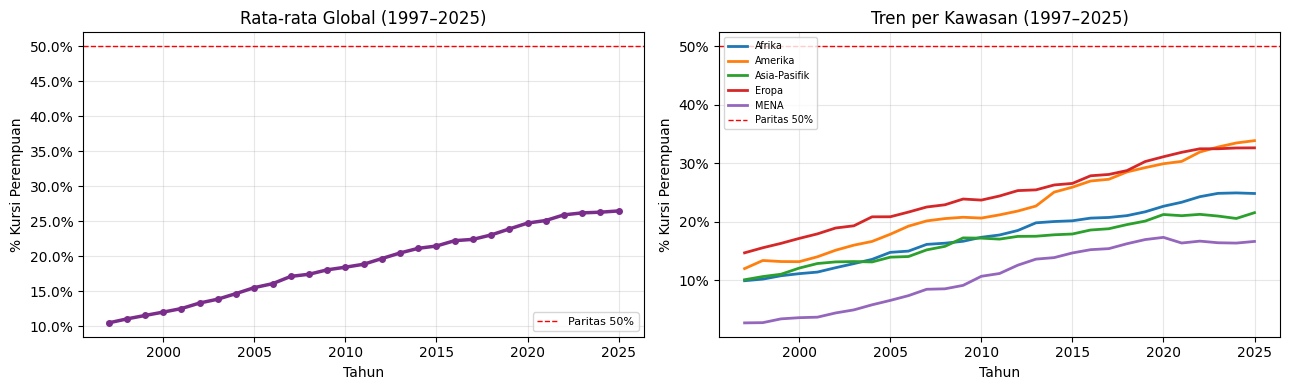

Plot disimpan: /content/drive/MyDrive/PetaKeheningan/output/eda_trend_plot.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Plot 1: Tren rata-rata global
global_trend = (
    df_panel.groupby('year')['pct_women']
    .mean()
    .reset_index()
)
ax = axes[0]
ax.plot(global_trend['year'], global_trend['pct_women'],
        color='#7B2D8B', lw=2.5, marker='o', ms=4)
ax.axhline(50, color='red', ls='--', lw=1, label='Paritas 50%')
ax.set_xlabel('Tahun')
ax.set_ylabel('% Kursi Perempuan')
ax.set_title('Rata-rata Global (1997–2025)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Plot 2: Tren per kawasan
region_trend = (
    df_panel.groupby(['year','region'])['pct_women']
    .mean()
    .reset_index()
)
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']
ax2 = axes[1]
for i, reg in enumerate(region_trend['region'].unique()):
    sub = region_trend[region_trend['region'] == reg]
    ax2.plot(sub['year'], sub['pct_women'],
             label=reg, lw=2, color=colors[i % len(colors)])
ax2.axhline(50, color='red', ls='--', lw=1, label='Paritas 50%')
ax2.set_xlabel('Tahun')
ax2.set_ylabel('% Kursi Perempuan')
ax2.set_title('Tren per Kawasan (1997–2025)')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.legend(fontsize=7, loc='upper left')
ax2.grid(alpha=0.3)

plt.tight_layout()
eda_path = os.path.join(OUTPUT_DIR, 'eda_trend_plot.png')
plt.savefig(eda_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Plot disimpan: {eda_path}")